In [1]:

import ee
import geemap
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [2]:
ee.Authenticate()


Successfully saved authorization token.


In [4]:
ee.Initialize(project="ee-martynadurda")

In [5]:
# Madrid
roi = ee.Geometry.Rectangle([-3.9, 40.3, -3.5, 40.6])

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(roi)
      .filterDate("2024-05-01", "2024-08-31")
      .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 10))
      .median()
      .clip(roi))

# Keeping a few bands (10m only)
bands = ["B2", "B3", "B4", "B8"]  # Blue, Green, Red, NIR
img = s2.select(bands)

# Scale reflectance (Sentinel-2 SR is scaled by 10000)
img = img.divide(10000)


In [6]:
lc = ee.Image("ESA/WorldCover/v200/2021").select("Map").clip(roi)

# masks
built = lc.eq(50)
trees = lc.eq(10)
water = lc.eq(80)

# Creating a single label image: 0 built, 1 trees, 2 water (masked elsewhere)
label = (ee.Image(0).where(trees, 1).where(water, 2)).updateMask(built.Or(trees).Or(water))

In [7]:

r = 3  # patch radius in pixels → patch size = (2r+1)x(2r+1)
kernel = ee.Kernel.square(radius=r, units="pixels", normalize=False)

# Converting neighborhood to bands: each patch becomes one long vector per band
patch_img = img.neighborhoodToBands(kernel)

# Adding label as a band so we can export it together
patch_img = patch_img.addBands(label.rename("label"))

In [8]:
n_per_class = 250  # adjustable
scale = 10  # Sentinel-2 10m

samples = patch_img.stratifiedSample(
    numPoints=n_per_class,
    classBand="label",
    region=roi,
    scale=scale,
    geometries=False
)

# Pull to Python
data = samples.getInfo()["features"]
print("Samples:", len(data))


Samples: 750


In [9]:
# Build a dataframe
rows = []
for f in data:
    props = f["properties"]
    rows.append(props)

df = pd.DataFrame(rows)
y = df["label"].astype(int).to_numpy()

# X: all patch bands except label
X = df.drop(columns=["label"]).to_numpy(dtype=float)

print(X.shape, y.shape)

     

(750, 196) (750,)


In [10]:

# standardize
Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=3, random_state=0)
Z = pca.fit_transform(Xz)

print("Explained variance:", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())

Explained variance: [0.5949938  0.11468365 0.05856443] sum: 0.768241891965551


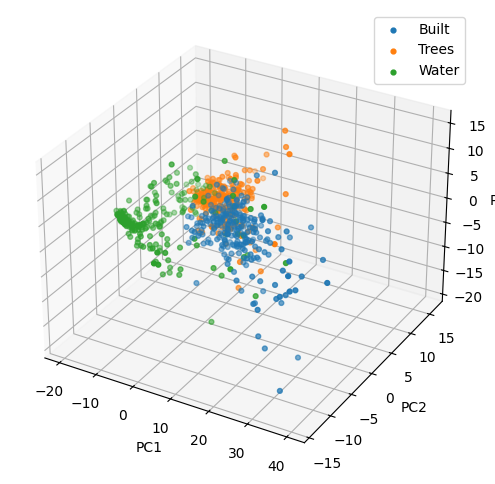

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

for cls, name in [(0,"Built"), (1,"Trees"), (2,"Water")]:
    idx = (y == cls)
    ax.scatter(Z[idx,0], Z[idx,1], Z[idx,2], s=12, label=name)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.legend()
plt.show()

Water (green)
Forms a tight and well-defined cluster, clearly separated from the other classes, primarily along PC1. This strong separation reflects the homogeneous spectral behavior of water and its low variability across pixels.

Trees (orange)
Appear as a moderately compact cluster, positioned between water and built-up areas. There is some overlap with the built-up class, indicating partial spectral similarity (e.g., shadows, mixed vegetation–urban pixels), but trees still maintain a recognizable structure in the feature space.

Built-up (blue)
Shows the most dispersed distribution, with a wide spread especially along PC1 and noticeable outliers. This dispersion reflects the high heterogeneity of urban surfaces, including roads, rooftops, and mixed materials with varying reflectance properties.

Overall:
Class separation is evident but not absolute, with overlap mainly between trees and built-up areas.
The clustering pattern is clearly structured rather than random.
PC1 provides the dominant discriminatory power, while PC2 and PC3 contribute secondary separation and refinement of class boundaries.

In [12]:

from sklearn.metrics import silhouette_score
sil = silhouette_score(Z, y)
print("Silhouette (in PC space):", sil)

Silhouette (in PC space): 0.272923456206515


The silhouette score computed in the PCA feature space is ≈ 0.27, which indicates moderate but not strong clustering. This suggests that the land-cover classes show some separation, but there is still noticeable overlap between them. The result is consistent with the PCA scatter plot, where water is relatively well separated, while trees and built-up areas partially overlap. Overall, the classes are distinguishable, but their boundaries are not sharply defined.
